## Tests y Visualizaciones

Para verificar el correcto funcionamiento del árbol se generaron **10.000 puntos aleatorios** con coordenadas $(x, y)$ en el rango $[0, 10000]$, simulando puntos de entrega distribuidos en una ciudad.

Se definió un punto objetivo en el centro del plano `(5000, 5000)` con un radio de búsqueda de **500 metros**. La búsqueda por radio retornó todos los puntos dentro de esa circunferencia, resaltados en verde en la visualización. Los **5 vecinos más cercanos** se marcan en azul con sus distancias anotadas, conectados al centro por líneas que permiten verificar visualmente que efectivamente son los más próximos.

La gráfica confirma que el árbol identifica correctamente los puntos dentro del radio y que los vecinos más cercanos son coherentes con su posición geométrica respecto al centro, con distancias que van desde los **31 m** hasta los **131 m** aproximadamente.

mostrando que el árbol de QuadTree funciona correctamente tanto para la búsqueda por radio como para la búsqueda de vecinos más cercanos, con resultados visuales claros y consistentes.

Raíz: [4999.5865395, 4998.7113795]
hijo de la raiz: [2499.84066675, 2499.5342487499997]
hijo del hijo de la raiz: [1249.967730375, 1249.9456833749998]
Resultados búsqueda por radio: [(4909.599805, 4535.127525), (4998.32665, 4557.845305), (4867.758334, 4663.490483), (4948.332143, 4639.13942), (4985.877761, 4642.672776), (4546.920658, 4861.393843), (4743.076363, 4732.752567), (4769.770879, 4692.231179), (4829.259988, 4761.625312), (4747.595525, 4787.343533), (4815.166494, 4788.146427), (4812.173441, 4842.490864), (4885.879201, 4697.525419), (4903.004853, 4734.484162), (4868.615627, 4821.100897), (4905.494965, 4838.727283), (4832.041536, 4878.54384), (4733.379715, 4947.888003), (4874.965131, 4861.009606), (4851.995145, 4929.8855), (4906.294059, 4995.844659), (5132.478432, 4567.984757), (5070.678173, 4627.116589), (5214.512147, 4580.425221), (5074.538343, 4757.377098), (5126.631104, 4692.323921), (5026.536119, 4798.523703), (5125.615042, 4771.080989), (5293.334811, 4760.441096), (5096.0836

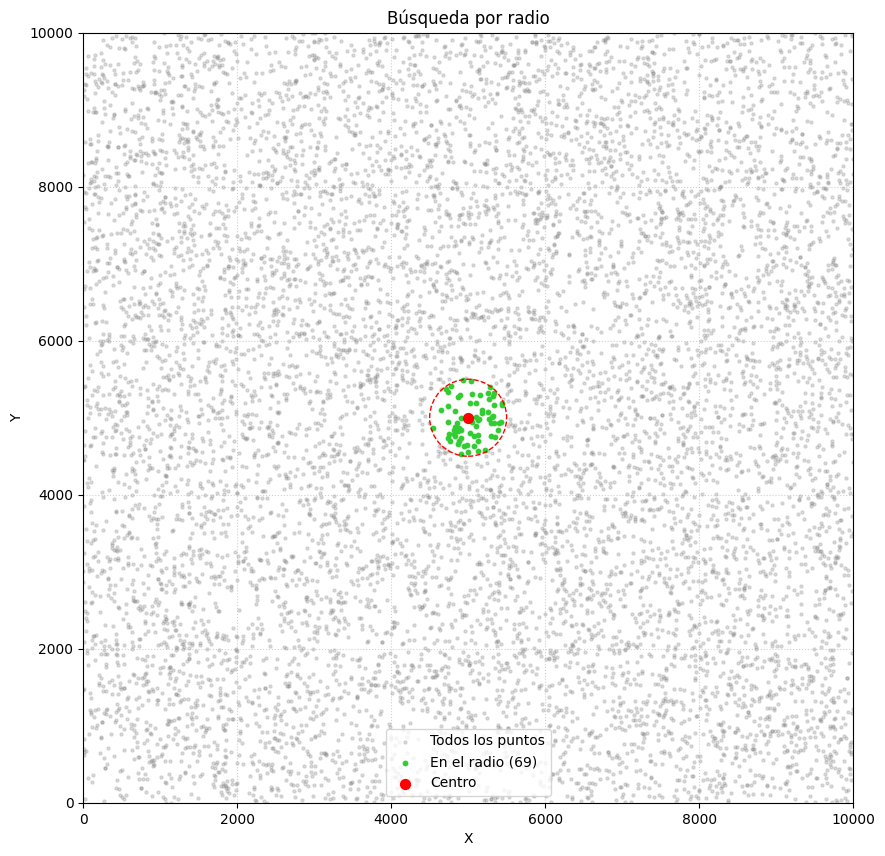

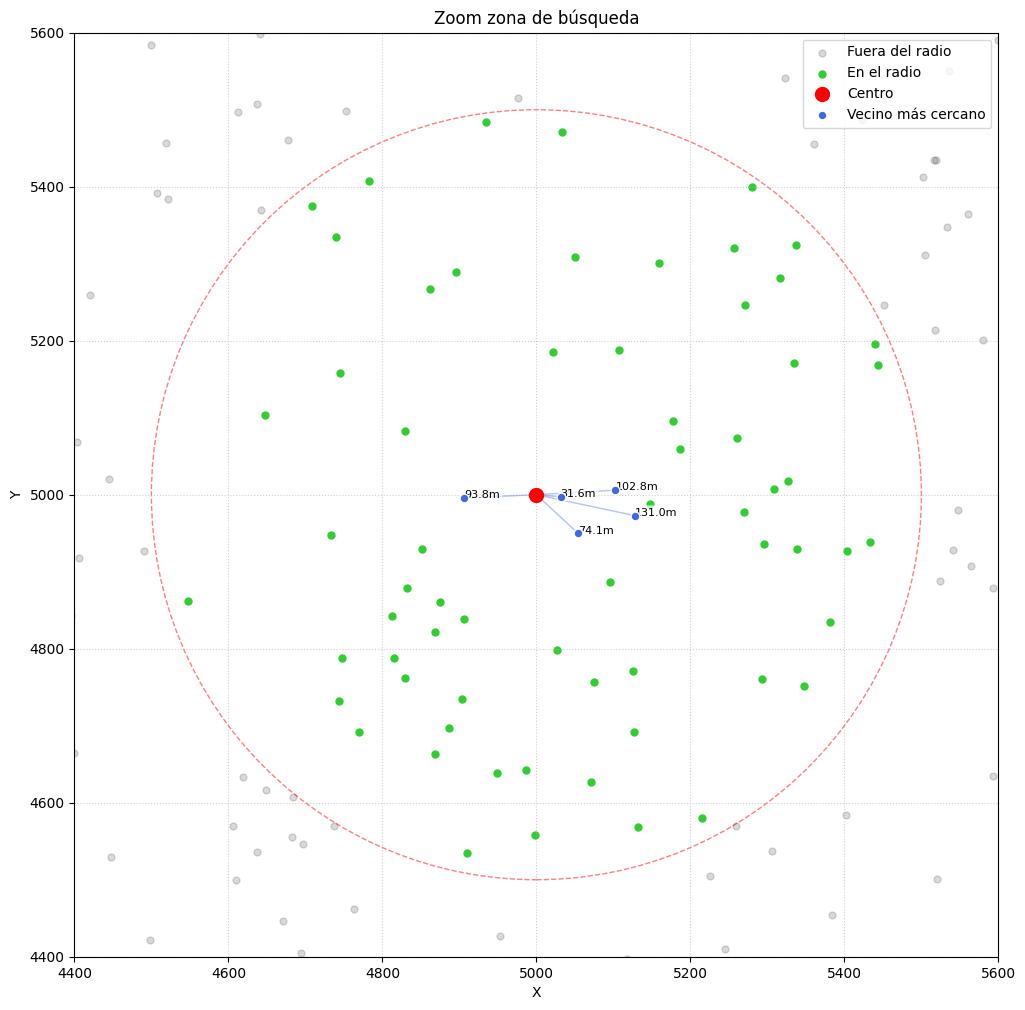

In [5]:
%run QuadTrees.ipynb
import random
import matplotlib.pyplot as plt

# Fijamos la semilla para que los resultados aleatorios sean reproducibles
random.seed(42)
#definimos los limites de donde se manejaran los datos
LAT_MIN, LAT_MAX =  0, 10000
LON_MIN, LON_MAX = 0, 10000

"""generamos lo 10,000 puntos aleatorios"""
#los parametros que se generaran aleatoriamente en las coordenadas x,y y el id que sale en orden
puntos = [
    {
        "id": i,
        "coordenadas": [
            round(random.uniform(LON_MIN, LON_MAX), 6),
            round(random.uniform(LAT_MIN, LAT_MAX), 6),
        ]
    }
    for i in range(10_000)
]


"""Visualizamos los puntos en un grafico de dispersion visualizando el radio y los puntos dentro de esta"""
def visualizar_radio(puntos, resultados, centro, radio):
    fig, ax = plt.subplots(figsize=(10, 10))

    x, y = zip(*puntos)
    ax.scatter(x, y, s=5, color="gray", alpha=0.25, label='Todos los puntos')

    if resultados:
        xr, yr = zip(*resultados)
        ax.scatter(xr, yr, s=10, color="limegreen", label=f'En el radio ({len(resultados)})')

    ax.scatter(*centro, s=50, color="red", zorder=5, label='Centro')
    ax.add_patch(plt.Circle(centro, radio, fill=False, color="red", linestyle='--'))

    ax.set(xlim=(0,10000), ylim=(0,10000), aspect='equal',
           title="Búsqueda por radio", xlabel="X", ylabel="Y")
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.6)
    plt.show()


"""visualizamos los vecinos mas cercanos del centro objetico"""
def visualizar_vecinos(puntos, resultados_radio, centro, radio, vecinos=None):
    fig, ax = plt.subplots(figsize=(12, 12))

    # Excluir puntos que ya se resaltan
    ids_excluir = set(resultados_radio)
    if vecinos:
        ids_excluir.update(vecinos)

    # Fondo y radio
    fondo = [p for p in puntos if p not in ids_excluir]
    if fondo:
        ax.scatter(*zip(*fondo), s=25, alpha=0.15, color='black', label='Fuera del radio')
    if resultados_radio:
        ax.scatter(*zip(*resultados_radio), s=25, color='limegreen', label='En el radio')

    # Centro y círculo
    ax.scatter(*centro, s=100, color='red', zorder=5, label='Centro')
    ax.add_patch(plt.Circle(centro, radio, fill=False, linestyle='--', color='red', alpha=0.5))

    # Vecinos y líneas
    if vecinos:
        for i, p in enumerate(vecinos):
            ax.plot([centro[0], p[0]], [centro[1], p[1]], color='royalblue', linewidth=1, alpha=0.4)
            ax.text(p[0], p[1], f"{plt.matplotlib.patches.FancyArrow and __import__('math').dist(p, centro):.1f}m",
                    fontsize=8, bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec='none'))
            ax.scatter(*p, s=40, color='royalblue', edgecolors='white', zorder=4,
                       label='Vecino más cercano' if i == 0 else None)

    # Zoom automático
    margen = radio * 0.2
    ax.set(xlim=(centro[0]-radio-margen, centro[0]+radio+margen),
           ylim=(centro[1]-radio-margen, centro[1]+radio+margen),
           aspect='equal', title="Zoom zona de búsqueda",
           xlabel="X", ylabel="Y")
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='upper right')
    plt.show()


puntos = [tuple(p["coordenadas"]) for p in puntos]
# Crear el árbol
arbol = QuadTree(puntos)



"""# ejemolos de prueba para verificar que el arbol se haya creado correctamente y que las funciones de busqueda esten funcionando"""
print(f"Raíz: {arbol.raiz.punto}")
print(f"hijo de la raiz: {arbol.raiz.hijos[0].punto}")
print(f"hijo del hijo de la raiz: {arbol.raiz.hijos[0].hijos[0].punto}")

"""definimos un punto objetivo y un radio de 500 metros"""
punto_objetivo = (5000, 5000)
radio = 500.0

resultados_radio = list(arbol.buscar_en_radio(arbol.raiz, punto_objetivo, radio))
print(f"Resultados búsqueda por radio: {resultados_radio}")

vecinos = arbol.buscar_vecinos_cercanos(punto_objetivo, k=5)
print(f"Vecinos más cercanos: {vecinos}")


visualizar_radio(puntos, resultados_radio, punto_objetivo, radio)
visualizar_vecinos(puntos, resultados_radio, punto_objetivo, radio, vecinos)

